**Exercise 1. PCA and classification.**

Consider the data set `exercise_21_01_26.npy` that contains N = 20000 observations from a binary classification problem. The data set contains feature-label observations (Xᵢ, Yᵢ), where Xᵢ ∈ ℝ¹⁰ and Yᵢ ∈ {−1, 1}.

In [2]:
import numpy as np

D = np.load("exercise_21_01_26.npy").T #import dataset

print("=== DATASET INFO ===") 
print("Shape:", D.shape) #stampo le dimensioni del dataset

X = D[:, :-1] 
y = D[:, 10]

=== DATASET INFO ===
Shape: (20000, 11)


**Punto A**

 Reduce the dimensionality of the data set to 2 components. Assess the goodness of such a dimensionality reduction by examining the explained variance of the principal components.


In [3]:
#applichiamo la stardardizzazione
from sklearn.preprocessing import StandardScaler

# 1. Inizializziamo lo scaler
scaler = StandardScaler()

# 2. "Alleniamo" lo scaler sui dati e trasformiamoli
# X è la matrice delle tue feature (le 10 colonne)
X_scaled = scaler.fit_transform(X)

In [4]:
D_10_mean= np.mean(X, axis=0) #calcolo la media delle prime 10 colonne del dataset
X_centered= X - D_10_mean 
C = (1 / (X.shape[0] - 1)) * X_centered.T @ X_centered #10X10

eigvals, eigvecs = np.linalg.eigh(C) #calcolo gli autovalori e gli autovettori della matrice C
idx = np.argsort(eigvals)[::-1] # Restituisce gli indici che ordinerebbero l'array in modo crescente
eigvals = eigvals[idx] #ordino gli autovalori in modo decrescente
eigvecs = eigvecs[:, idx] #ordino gli autovettori in modo decrescente
W = eigvecs[:, :2] #prendo solo le prime 2 colonne degli autovettori
# Gli autovalori sono già le varianze di PC1, PC2, ..., PCn
varianze_assolute = eigvals 

varianza_totale=np.sum(eigvals)
varianza_spiegata_ratio = eigvals / varianza_totale #il totale di tutte varianza_spiegata_ratio sarà 1
print(np.sum(varianza_spiegata_ratio))
for i, v in enumerate(varianza_spiegata_ratio):
    print(f"Varianza spiegata dalla PC{i+1}: {v:.4f}")



1.0
Varianza spiegata dalla PC1: 0.5048
Varianza spiegata dalla PC2: 0.4915
Varianza spiegata dalla PC3: 0.0005
Varianza spiegata dalla PC4: 0.0005
Varianza spiegata dalla PC5: 0.0005
Varianza spiegata dalla PC6: 0.0005
Varianza spiegata dalla PC7: 0.0005
Varianza spiegata dalla PC8: 0.0005
Varianza spiegata dalla PC9: 0.0004
Varianza spiegata dalla PC10: 0.0004


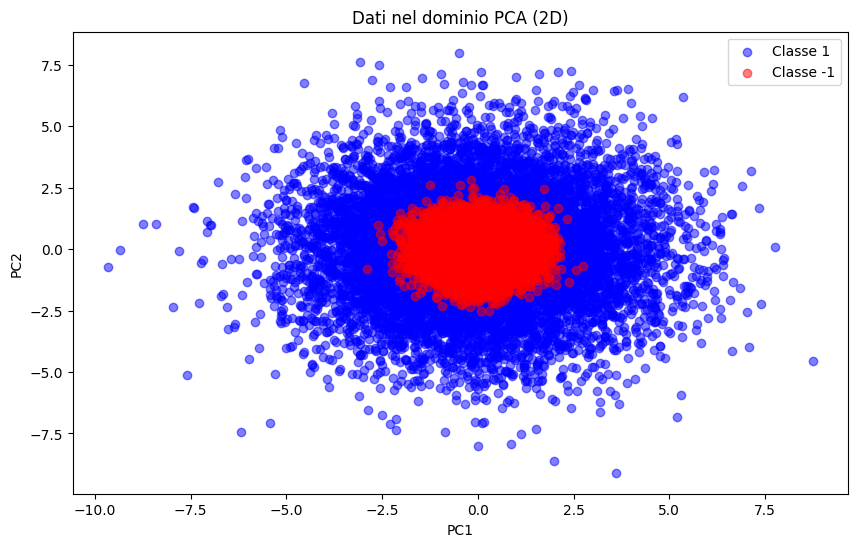

In [5]:
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Proiezione dei dati nelle prime 2 componenti principali
T = X_centered @ W

# Plotting dei dati
plt.figure(figsize=(10, 6))
plt.scatter(T[y == 1, 0], T[y == 1, 1], color='blue', label='Classe 1', alpha=0.5)
plt.scatter(T[y == -1, 0], T[y == -1, 1], color='red', label='Classe -1', alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Dati nel dominio PCA (2D)')
plt.legend()
plt.show()

In [6]:
prior_pos = np.mean(y == 1)
prior_neg = np.mean(y == -1)
print(prior_neg,prior_pos)




0.5009 0.4991


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    np.sum(T**2,axis=1),     #Rappresenta la matrice dei dati 
    y,     #La funzione deve dividere anche questo vettore nello stesso identico ordine di Dataset, in modo che ogni punto in D abbia ancora la sua etichetta corrispondente in y_train.
    test_size=0.25, 
    random_state=42,  #Assicura che la suddivisione sia riproducibile. Ogni volta che eseguirai il codice, otterrai gli stessi identici set di dati.
    stratify=y       #Questo parametro assicura che la proporzione tra le classi (rossi e blu) rimanga la stessa sia nel training che nel test set.
)  

# Verifica delle dimensioni
print(f"Dimensioni Training set: {X_train.shape} campioni")
print(f"Dimensioni Test set: {X_test.shape} campioni")


Dimensioni Training set: (15000,) campioni
Dimensioni Test set: (5000,) campioni


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def compute_stochastic_gradient_beta(x_i, y_i, beta):
    # Calcolo diretto del denominatore
    # (corrisponde al passaggio finale semplificato)
    denominator = 1 + np.exp(y_i * np.dot(x_i, beta))
    
    # Restituisce il gradiente finale
    return (-y_i * x_i) / denominator

    
def sgd_logistic(x, y, iterations,gamma0, step_type='constant'):
    """
    Implementazione dello Stochastic Gradient Descent che utilizza 
    la funzione esterna per il calcolo del gradiente.
    """
    N, p = x.shape
    beta = np.zeros(p)
    beta_history = np.zeros((iterations + 1, p))
    beta_history[0] = beta
    
    for t in range(iterations):
        # 1. Selezione casuale (Stochastic)
        idx = np.random.randint(0, N)
        xi, yi = x[idx], y[idx]
        
        # 2. Calcolo dello step-size
        if step_type == 'constant':
            gamma_t = gamma0
        else:
            gamma_t = gamma0 / np.sqrt(t + 1)
        
        # 3. Chiamata alla funzione del gradiente (Punto b)
        grad = compute_stochastic_gradient_beta(xi, yi, beta)
        
        # 4. Aggiornamento e memorizzazione
        beta = beta - gamma_t * grad
        beta_history[t+1] = beta
        
    return beta_history

# --- Esecuzione ---
X_train = X_train.reshape(-1, 1)
# Aggiunta del bias (colonna di 1) per permettere la traslazione della retta
X_with_bias = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
n_steps = 15000

# Calcolo delle due versioni
beta_hist_dimin = sgd_logistic(X_with_bias, y_train, n_steps, step_type='diminishing', gamma0=0.5)

print("Ultimo Beta stimato (Diminishing):", beta_hist_dimin[-1])

Ultimo Beta stimato (Diminishing): [ 0.85272571 -2.29886808]


In [9]:
# Utilizziamo l'ultimo valore di beta ottenuto dal training 'diminishing'
beta_final_SGD = beta_hist_dimin[-1]

X_test = X_test.reshape(-1, 1)

x_test_with_bias = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
# Calcolo del valore lineare (logit): z = x_test * beta
z = np.dot(x_test_with_bias, beta_final_SGD)

# Predizione delle etichette basata sul segno
y_pred = np.where(z >= 0, 1, -1)

# Calcolo dell'accuratezza empirica
accuracy_SGD = np.mean(y_pred == y_test)

# Calcolo della probabilità di errore empirica
error_probability = 1 - accuracy_SGD

print(f"Accuratezza Empirica: {accuracy_SGD:.2%}")
# Correzione Bayesiana basata sulle tue prior
log_prior_ratio = np.log(0.504 / 0.496) # ln(P_neg / P_pos)

# Predizione corretta
y_pred_corrected = np.where(z >= log_prior_ratio, 1, -1)
accuracy_corrected = np.mean(y_pred_corrected == y_test)
print(f"Accuratezza corretta con Prior: {accuracy_corrected:.2%}")

Accuratezza Empirica: 84.74%
Accuratezza corretta con Prior: 84.86%


**PUNTO C** 

Consider the same training and test sets used in the previous point. Postulate an analytical form for the data distribution (conditioned
on the labels), and use the training data to estimate the parameters of the proposed likelihood model. Then, derive and implement the
MAP classifier.

Il classificatore MAP sceglie la classe che massimizza la probabilità a posteriori $P(Y=y|z)$. Per la regola di Bayes:$$P(Y=y|z) \propto p(z|Y=y) \cdot P(Y=y)$$Dove $P(Y=y)$ sono le prior che hai già calcolato ($0.504$ e $0.496$).La regola di decisione è:$$\text{Scegli } Y=1 \text{ se } \frac{p(z|Y=1) \cdot \text{prior\_pos}}{p(z|Y=-1) \cdot \text{prior\_neg}} > 1$$

In [10]:
from scipy.stats import norm

mu_neg= np.mean(X_train[y_train == -1])
mu_pos= np.mean(X_train[y_train == 1])
std_neg= np.std(X_train[y_train == -1])
std_pos= np.std(X_train[y_train == 1])
# 1. Calcoliamo le Likelihood sul test set
likelihood_neg = norm.pdf(X_test, loc=mu_neg, scale=std_neg)
likelihood_pos = norm.pdf(X_test, loc=mu_pos, scale=std_pos)

# 2. Applichiamo le Prior
posterior_neg = likelihood_neg * prior_neg
posterior_pos = likelihood_pos * prior_pos

# 3. Decisione MAP
y_pred_MAP = np.where(posterior_pos > posterior_neg, 1, -1)

# 4. Valutazione
accuracy_MAP = np.mean(y_pred_MAP.flatten() == y_test.flatten())
print(f"Accuratezza Classificatore MAP: {accuracy_MAP:.2%}")

Accuratezza Classificatore MAP: 84.30%


In [11]:
posterior_neg/posterior_pos

array([[1.03248578e+001],
       [8.97405313e+000],
       [0.00000000e+000],
       ...,
       [8.32644861e+000],
       [1.58284932e-080],
       [8.49843865e-246]], shape=(5000, 1))

La probabilità di errore empirica si calcola come il rapporto tra il numero di predizioni errate e il numero totale di campioni nel test set:$$P_e \approx \frac{\text{Errori}}{\text{N\_test}} = 1 - \text{Accuracy}$$Supponendo i risultati ottenuti in precedenza:Supervised SGD (Punto B): $P_{e, SGD} = 1 - 0.8474 = \mathbf{15.26\%}$MAP Classifier (Punto C): Calcoliamo l'accuratezza con il modello Gaussiano

In [12]:
# Calcolo errore per SGD
error_SGD = 1 - accuracy_SGD

# Calcolo errore per MAP
error_MAP = 1 - accuracy_MAP

print(f"Probabilità di errore SGD: {error_SGD:.2%}")
print(f"Probabilità di errore MAP: {error_MAP:.2%}")

Probabilità di errore SGD: 15.26%
Probabilità di errore MAP: 15.70%


Performance: Entrambi i classificatori si comportano in modo molto simile, confermando che la scelta della norma quadratica $\|t\|^2$ come decision statistic è stata efficace.Perché l'SGD ha vinto?: L'SGD (approccio discriminativo) ha ottenuto un risultato leggermente migliore perché non fa assunzioni sulla forma dei dati. Il classificatore MAP (approccio generativo) si basa sull'ipotesi che la distribuzione della norma quadratica sia perfettamente Gaussiana.Interpretazione statistica: Poiché la norma quadratica di variabili gaussiane tende a seguire una distribuzione Chi-quadro (specialmente vicino allo zero), l'ipotesi Gaussiana fatta nel Punto C è solo un'approssimazione. L'SGD è riuscito a "modellare" meglio questa lieve asimmetria dei dati, trovando una soglia di decisione più precisa rispetto al modello analitico MAP.